/Users/tanguy/.local/share/micromamba/envs/hag_env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


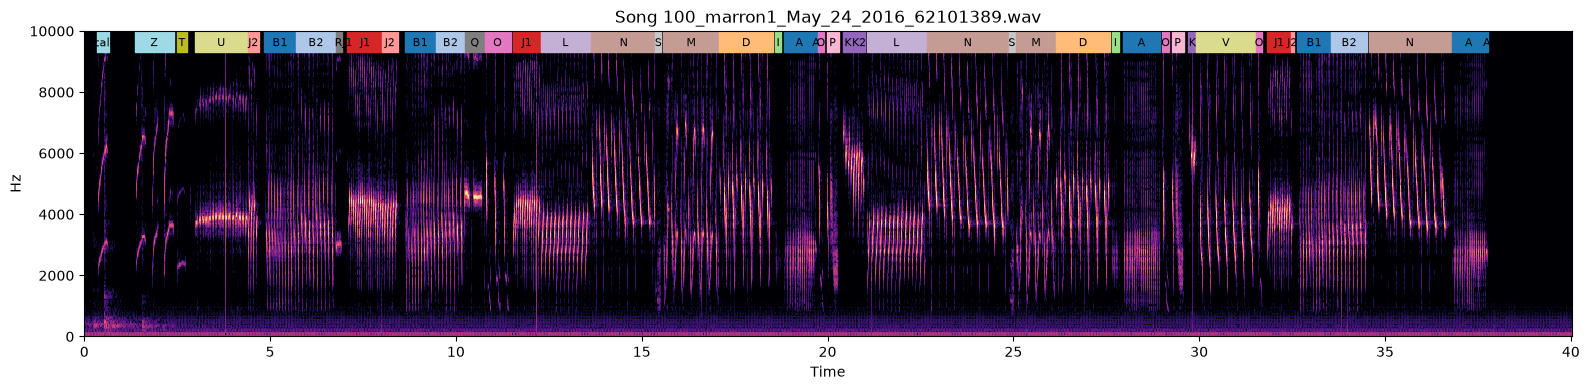

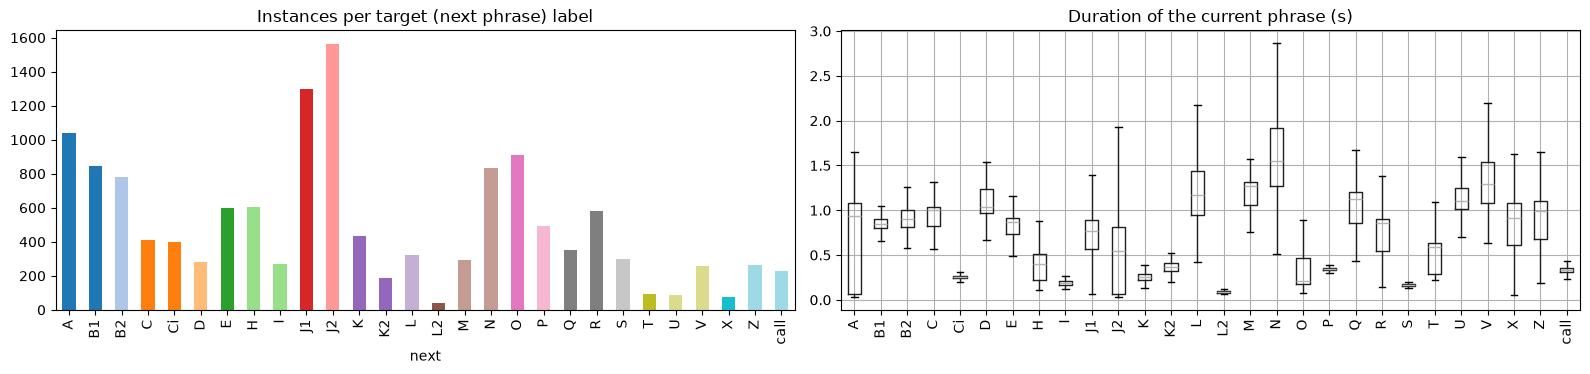

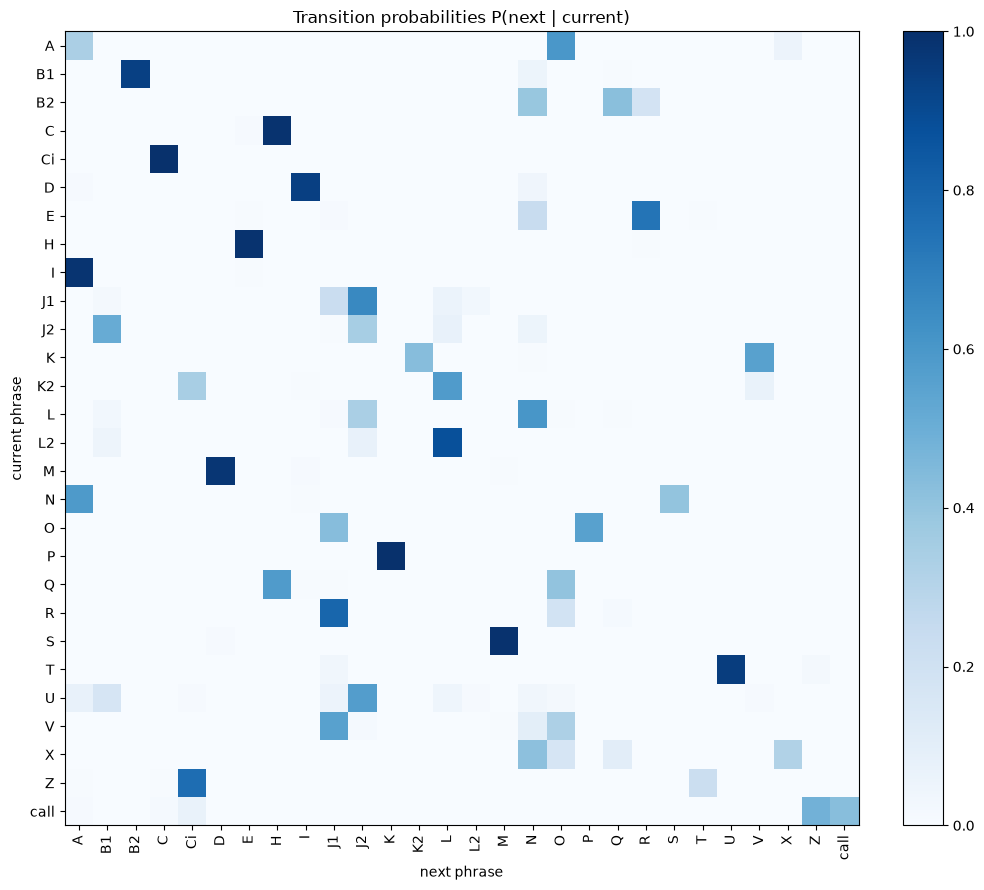

Most-frequent-successor baseline accuracy (knowing only the current label): 0.698
Majority-class baseline accuracy: 0.113


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import librosa
import librosa.display
import soundfile as sf

from hag.datasets.load_categorical_forecasting import download_canary_if_needed, build_phrase_sequences

annotations_dir, audio_dir = download_canary_if_needed()
annotations = pd.concat([pd.read_csv(f, index_col=0) for f in sorted(annotations_dir.rglob("*.csv"))])
pairs = build_phrase_sequences(annotations)  # one row per instance: current phrase -> next label
labels = sorted(set(pairs["current"]) | set(pairs["next"]))
colors = dict(zip(labels, plt.cm.tab20(np.linspace(0, 1, len(labels)))))

# 1. One song: spectrogram with its phrase annotations
wave = annotations["wave"].unique()[0]
song = annotations[annotations["wave"] == wave]
audio, sr = sf.read(next(audio_dir.rglob(wave)), dtype="float32")
S = librosa.amplitude_to_db(np.abs(librosa.stft(audio, n_fft=1024, hop_length=256)), ref=np.max)

fig, ax = plt.subplots(figsize=(16, 4))
librosa.display.specshow(S, sr=sr, hop_length=256, x_axis="time", y_axis="hz", ax=ax, cmap="magma")
ax.set_ylim(0, 10000)
for start, end, label in song[["start", "end", "syll"]].itertuples(index=False):
    if label in ("SIL", "TRASH"):
        continue
    ax.axvspan(start, end, ymin=0.93, ymax=1, color=colors.get(label, "grey"))
    ax.text((start + end) / 2, 9600, label, ha="center", va="center", fontsize=8, color="black")
ax.set_title(f"Song {wave}")
plt.tight_layout()
plt.show()

# 2. Number of instances and duration per phrase label
durations = pairs.assign(duration=pairs["end"] - pairs["start"])
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 4))
pairs["next"].value_counts().reindex(labels).plot.bar(ax=ax1, color=[colors[l] for l in labels])
ax1.set_title("Instances per target (next phrase) label")
durations.boxplot(column="duration", by="current", ax=ax2, rot=90, showfliers=False)
ax2.set_title("Duration of the current phrase (s)")
ax2.set_xlabel("")
fig.suptitle("")
plt.tight_layout()
plt.show()

# 3. Song syntax: P(next | current) transition matrix
transitions = pd.crosstab(pairs["current"], pairs["next"], normalize="index").reindex(index=labels, columns=labels, fill_value=0)
fig, ax = plt.subplots(figsize=(10, 9))
im = ax.imshow(transitions, cmap="Blues", vmin=0, vmax=1)
ax.set_xticks(range(len(labels)), labels, rotation=90)
ax.set_yticks(range(len(labels)), labels)
ax.set_xlabel("next phrase")
ax.set_ylabel("current phrase")
ax.set_title("Transition probabilities P(next | current)")
fig.colorbar(im, ax=ax, fraction=0.046)
plt.tight_layout()
plt.show()

# Baseline: always predict the most frequent successor of the current phrase
best_next = pairs.groupby("current")["next"].agg(lambda s: s.value_counts().index[0])
baseline = (pairs["current"].map(best_next) == pairs["next"]).mean()
print(f"Most-frequent-successor baseline accuracy (knowing only the current label): {baseline:.3f}")
print(f"Majority-class baseline accuracy: {pairs['next'].value_counts(normalize=True).iloc[0]:.3f}")

Number of songs = 459
Number of instances (train / test) = 11089 / 2765
Number of classes = 28
Using MFCC config: {'sr': 16000, 'n_mfcc': 13, 'win_length': 372, 'hop_length': 186, 'n_fft': 743, 'fmin': 500, 'fmax': 8000, 'lifter': 40, 'deltas': True}


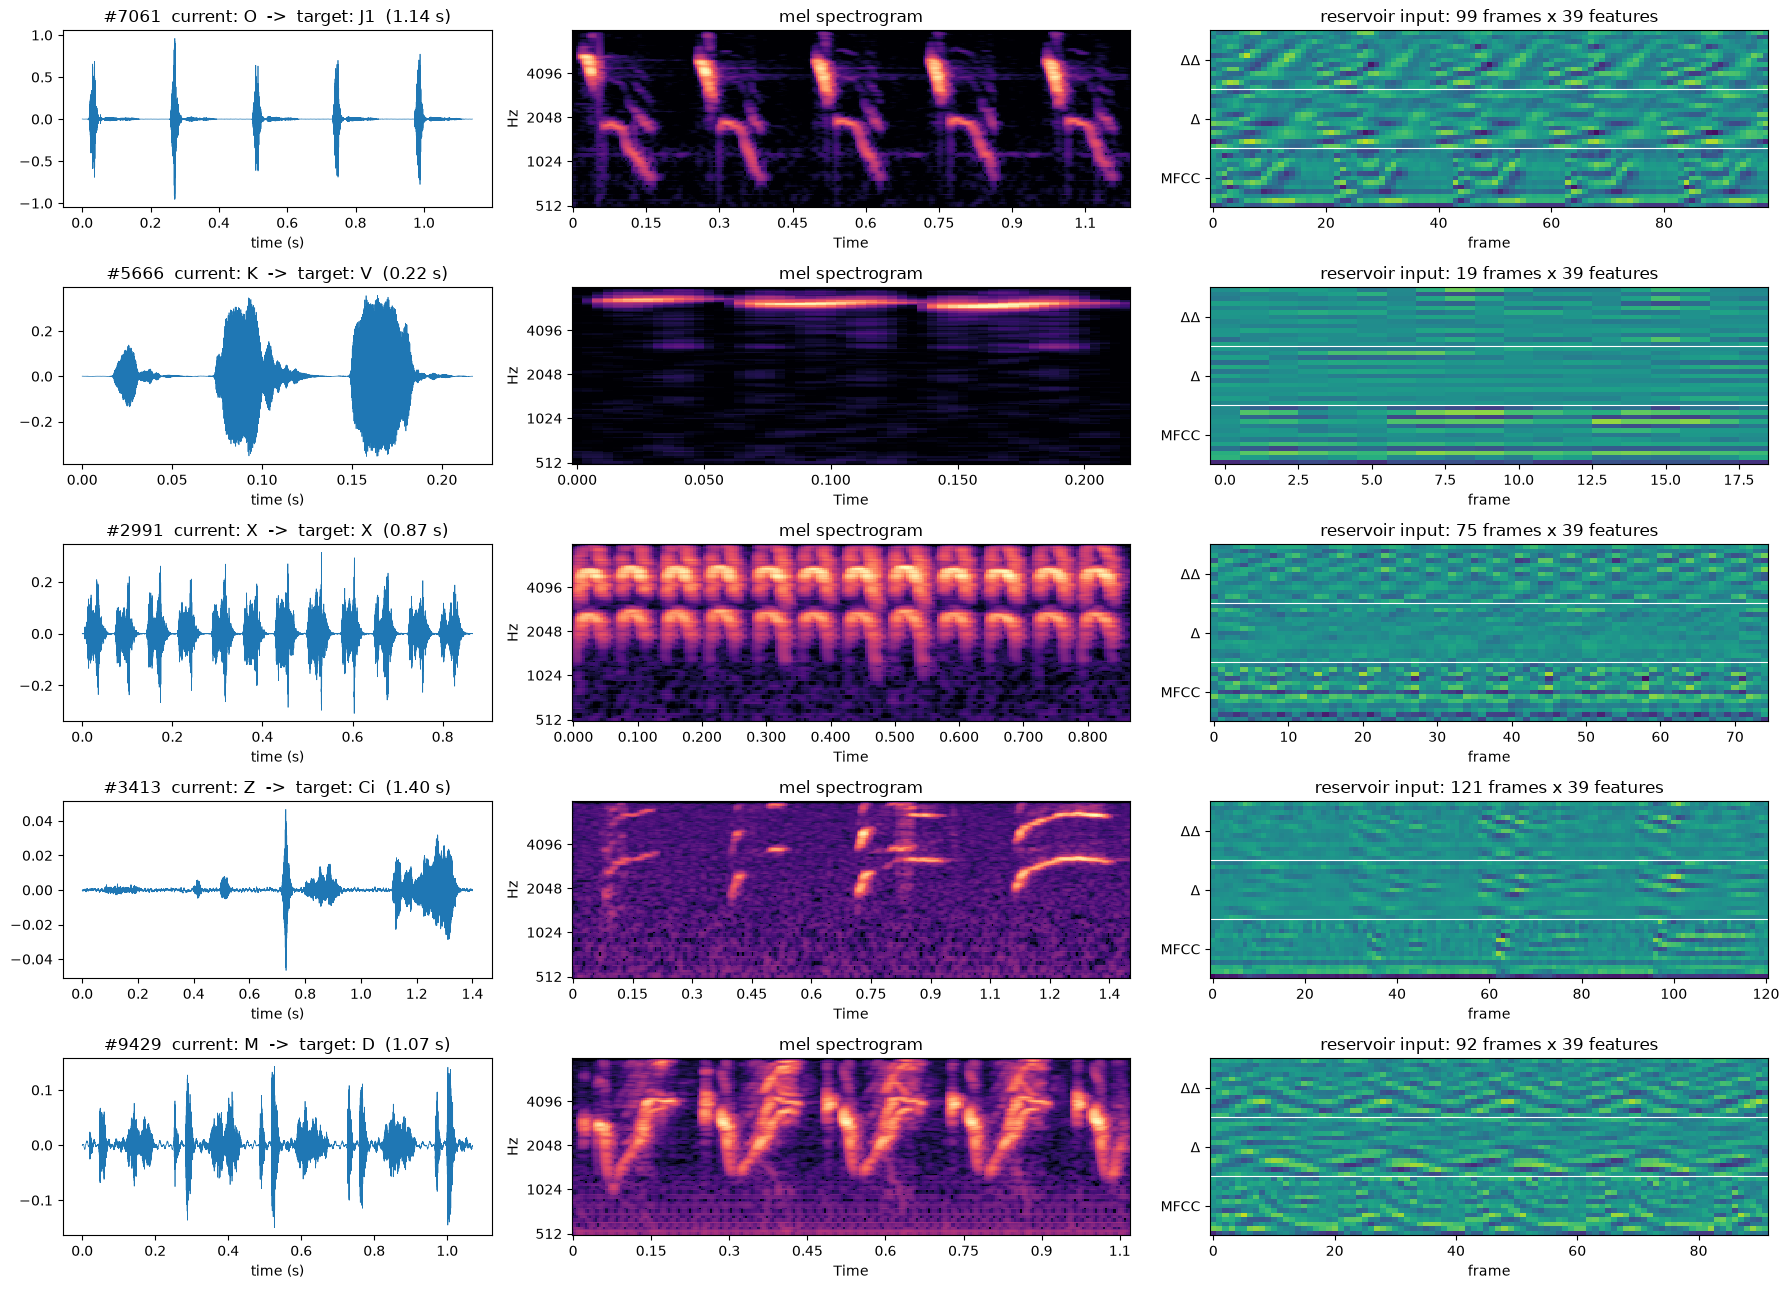

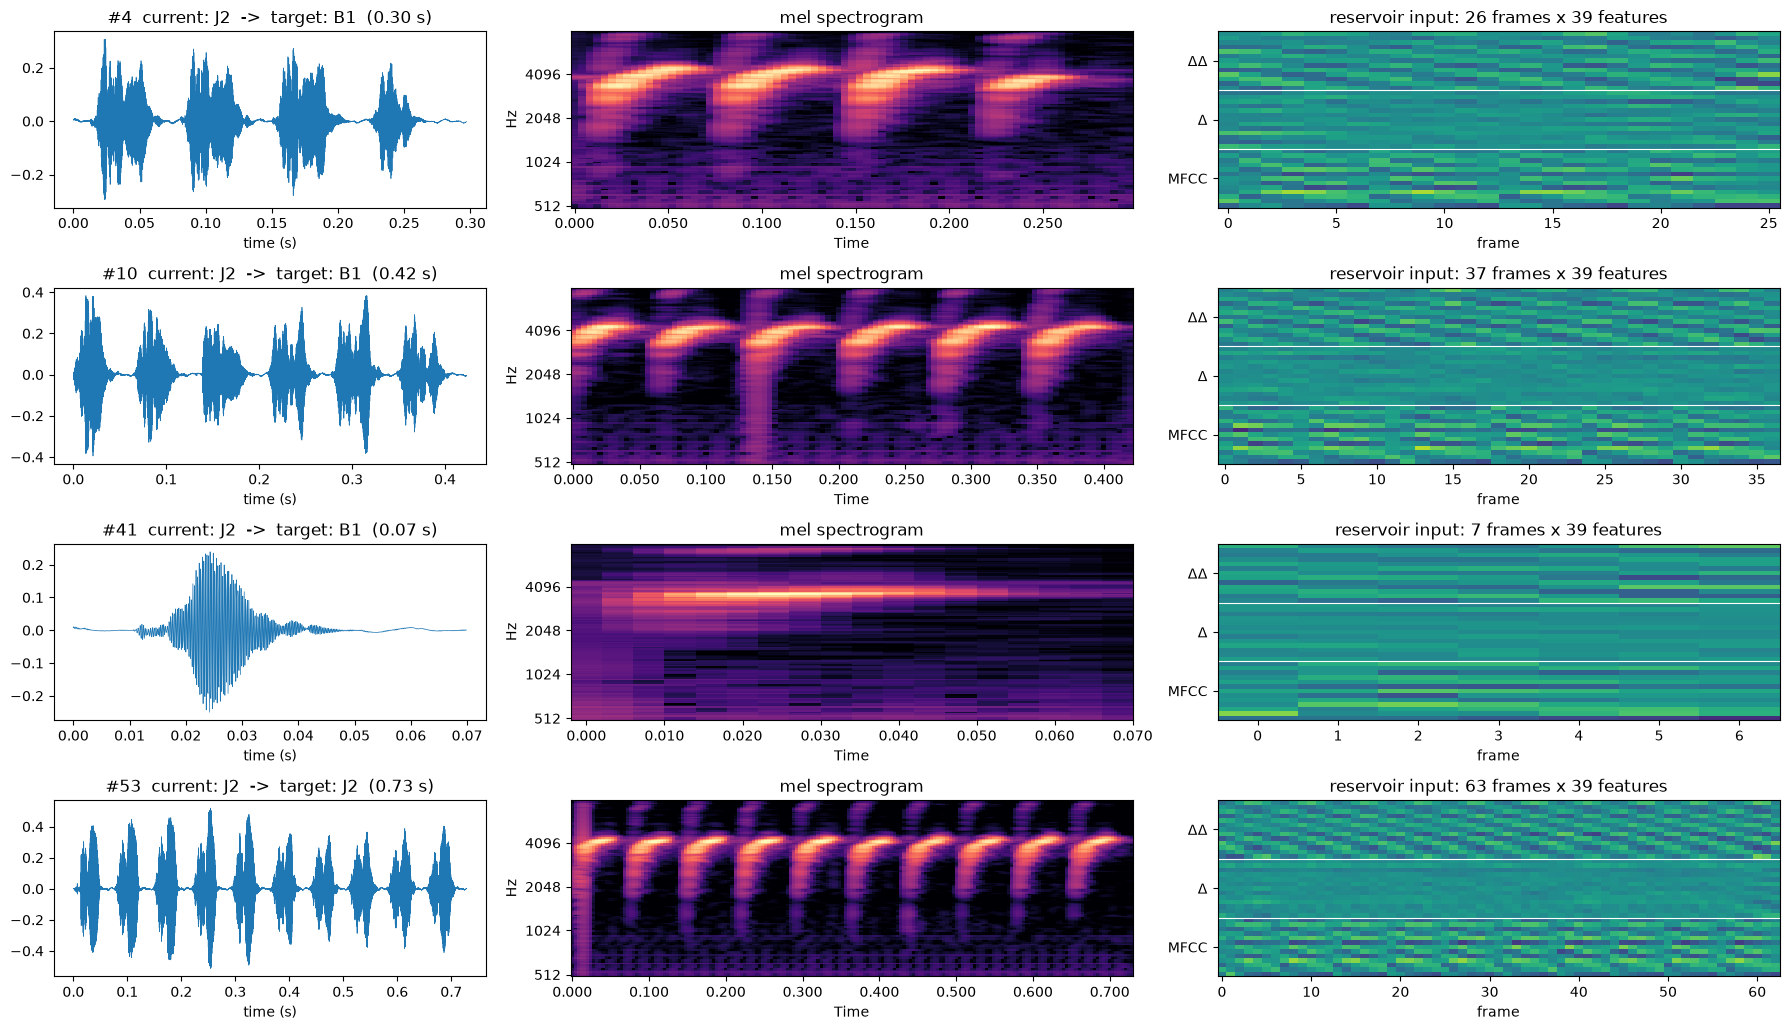

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import librosa
import librosa.display
from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import MinMaxScaler

from hag.datasets.load_categorical_forecasting import (load_canary_dataset, build_phrase_sequences,
                                                       download_canary_if_needed, canary_mfcc_config,
                                                       CANARY_SPLIT_SEED)
from hag.datasets.spectral_decomposition import generate_multivariate_dataset
from hag.datasets.preprocessing import scale_data

sr, X_train, X_test, Y_train, Y_test, groups, classes = load_canary_dataset()

# Current phrase label of each training instance (the loader only returns the target = next label):
# rebuild the same pairs and the same song split, and check they are aligned with X_train
annotations_dir, _ = download_canary_if_needed()
annotations = pd.concat([pd.read_csv(f, index_col=0) for f in sorted(annotations_dir.rglob("*.csv"))])
pairs = build_phrase_sequences(annotations)
train_idx, _ = next(GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=CANARY_SPLIT_SEED).split(pairs, groups=pairs["wave"]))
train_pairs = pairs.iloc[train_idx].reset_index(drop=True)
assert (train_pairs["wave"].to_numpy() == groups).all() and (train_pairs["next"].to_numpy() == classes[Y_train.argmax(1)]).all()

# Model input: MFCC + deltas, MinMax-scaled on the training set (as in hpo_esn.py)
X_train_band = generate_multivariate_dataset(X_train, True, "mfcc", mfcc_config=canary_mfcc_config(sr), verbosity=0)
X_train_band, _, _ = scale_data(X_train_band, None, None, MinMaxScaler(feature_range=(0, 1)), True)

def show_examples(indices):
    fig, axes = plt.subplots(len(indices), 3, figsize=(18, 2.6 * len(indices)), gridspec_kw={"width_ratios": [1, 1.3, 1.3]})
    for row, i in zip(np.atleast_2d(axes), indices):
        audio = X_train[i].ravel()
        current, target = train_pairs.loc[i, "current"], train_pairs.loc[i, "next"]

        row[0].plot(np.arange(len(audio)) / sr, audio, lw=0.5)
        row[0].set_title(f"#{i}  current: {current}  ->  target: {target}  ({len(audio) / sr:.2f} s)")
        row[0].set_xlabel("time (s)")

        mel = librosa.power_to_db(librosa.feature.melspectrogram(y=audio, sr=sr, n_fft=512, hop_length=64, fmin=500, fmax=8000), ref=np.max)
        librosa.display.specshow(mel, sr=sr, hop_length=64, x_axis="time", y_axis="mel", fmin=500, fmax=8000, ax=row[1], cmap="magma")
        row[1].set_title("mel spectrogram")

        row[2].imshow(X_train_band[i].T, aspect="auto", origin="lower", cmap="viridis", vmin=0, vmax=1)
        row[2].axhline(12.5, color="w", lw=0.8)
        row[2].axhline(25.5, color="w", lw=0.8)
        row[2].set_yticks([6, 19, 32], ["MFCC", "Δ", "ΔΔ"])
        row[2].set_title(f"reservoir input: {X_train_band[i].shape[0]} frames x {X_train_band[i].shape[1]} features")
        row[2].set_xlabel("frame")
    plt.tight_layout()
    plt.show()

rng = np.random.default_rng(0)
show_examples(rng.choice(len(X_train), 5, replace=False))             # random examples
show_examples(train_pairs.index[train_pairs["current"] == "J2"][:4])  # one phrase type, its different targets

## HAG : `HAGReservoir` (nœud reservoirpy) vs `run_algorithm` (version de base)

Pour chaque dataset et chaque fonction (`mean_hag`, `var_hag`), avec les meilleurs hyperparamètres des études Optuna :

1. **Poids** : même initialisation et mêmes tirages aléatoires (RNG global de numpy) → le `W` appris par `HAGReservoir.fit` doit être identique à celui de `run_algorithm` (écart max attendu : 0).
2. **Test** : `evaluate_dataset_on_test` avec la même graine, une fois avec `run_algorithm`, une fois avec `use_hag_node=True` (HAG entraîné puis exécuté par `HAGReservoir`) → mêmes scores attendus.
3. **Graines indépendantes** (optionnel, `INDEPENDENT_SEEDS = True`) : le nœud avec ses propres graines (`seed=...`), comme on l'utiliserait en pratique → mêmes performances aux fluctuations près.

In [ ]:
import math
import time

import numpy as np
import pandas as pd
from numpy import random
from scipy import stats

from hag.analysis.commons import load_data, evaluate_dataset_on_test, study_db_dir, activation_function
from hag.hag.hag import run_algorithm
from hag.hpo.utility import retrieve_best_model
from hag.hpo.utility import hag_reservoir_from_hyperparameters
from hag.models.reservoir import init_matrices

DATASETS = ["JapaneseVowels", "CatsDogs", "FSDD", "SpokenArabicDigits", "SPEECHCOMMANDS"]
FUNCTIONS = ["mean_hag", "var_hag"]
SEED = 923984           # graine de evaluate_dataset_on_test (identique pour les deux versions)
NB_TRIALS = 8           # nb de réservoirs évalués sur le test
N_W_CHECK = 3           # nb de tirages pour la comparaison exacte des poids
INDEPENDENT_SEEDS = False  # True : ajoute le nœud avec ses propres graines (comparaison statistique)


def best_hyperparameters(function, dataset, is_multivariate):
    study = retrieve_best_model(function, dataset, is_multivariate, prefix="tpe", db_dir=study_db_dir(dataset), verbosity=0)
    hp = dict(study.best_trial.params)
    if 'variance_target' not in hp and 'min_variance' in hp:
        hp['variance_target'] = hp['min_variance']
    return study, hp


def hag_matrices(hp, input_dim):
    """Matrices initiales de HAG, comme dans evaluate_dataset_on_test (graine tirée du RNG global)."""
    K = math.ceil(hp['network_size'] / input_dim)
    Win, W, bias = init_matrices(input_dim * K, 1, hp['connectivity'], K, w_distribution=stats.uniform(loc=-1, scale=2),
                                 seed=random.randint(0, 1000))
    return W, Win * hp['input_scaling'], bias * hp['bias_scaling']


def W_run_algorithm(hp, function, pretrain, seed):
    random.seed(seed)
    W, Win, bias = hag_matrices(hp, pretrain[0].shape[1])
    if function == "mean_hag":
        target, spread, extra = hp['target_rate'], hp['rate_spread'], {}
    else:
        target, spread = hp['variance_target'], hp['variance_spread']
        extra = dict(intrinsic_saturation=hp['intrinsic_saturation'], intrinsic_coef=hp['intrinsic_coef'])
    W, _ = run_algorithm(W, Win, bias, hp['leaky_rate'], activation_function, pretrain, hp['weight_increment'], target,
                         spread, function, multiple_instances=True, min_increment=hp['min_increment'],
                         max_increment=hp['max_increment'], use_full_instance=hp['use_full_instance'],
                         max_partners=np.inf, method="pearson", n_jobs=1, progress_bar=False, **extra)
    return W


def W_hag_node(hp, function, pretrain, seed):
    random.seed(seed)
    W, Win, bias = hag_matrices(hp, pretrain[0].shape[1])
    # rng=random.mtrand._rand : RNG global de numpy, donc les mêmes tirages que run_algorithm
    node = hag_reservoir_from_hyperparameters(hp, function, input_dim=pretrain[0].shape[1], W=W, Win=Win, bias=bias,
                                             rng=random.mtrand._rand)
    return node.fit(list(pretrain)).W


def evaluate_independent_node(hp, function, pretrain, train, test, Y_train, Y_test, nb_trials, seed):
    """Nœud utilisé « normalement » : ses propres graines, readout Ridge sur le dernier état (comme le pipeline de base)."""
    from hag.performances.esn_model_evaluation import (init_readout, train_model_for_classification,
                                                       predict_model_for_classification, compute_score)
    scores = []
    for k in range(nb_trials):
        node = hag_reservoir_from_hyperparameters(hp, function, input_dim=pretrain[0].shape[1], seed=seed + k)
        node.fit(list(pretrain)).reset()
        readout = init_readout(ridge_coef=10 ** hp['ridge'])
        train_model_for_classification(node, readout, train, Y_train, mode="sequence-to-vector")
        Y_pred = predict_model_for_classification(node, readout, test, mode="sequence-to-vector")
        scores.append(compute_score(Y_pred, Y_test, True))
    return scores

In [ ]:
rows = []
for dataset in DATASETS:
    pretrain, train, test, Y_train, Y_test, is_multivariate, is_classif = load_data(dataset, "mfcc")
    for function in FUNCTIONS:
        print(f"===== {dataset} / {function}")
        study, hp = best_hyperparameters(function, dataset, is_multivariate)

        # 1. poids : écart max entre les deux versions, mêmes tirages
        w_diff = max(np.abs(W_run_algorithm(hp, function, pretrain, s) - W_hag_node(hp, function, pretrain, s)).max()
                     for s in range(N_W_CHECK))

        # 2. test, même graine
        t = time.time()
        base = evaluate_dataset_on_test(study, dataset, function, pretrain, train, test, Y_train, Y_test, is_classif,
                                        nb_trials=NB_TRIALS, seed=SEED)
        t_base, t = time.time() - t, time.time()
        node = evaluate_dataset_on_test(study, dataset, function, pretrain, train, test, Y_train, Y_test, is_classif,
                                        nb_trials=NB_TRIALS, seed=SEED, use_hag_node=True)
        t_node = time.time() - t

        row = {"dataset": dataset, "function": function, "max_W_diff": w_diff,
               "run_algorithm_mean_%": 100 * np.mean(base), "run_algorithm_std_%": 100 * np.std(base),
               "HAGReservoir_mean_%": 100 * np.mean(node), "HAGReservoir_std_%": 100 * np.std(node),
               "identical_scores": bool(np.array_equal(base, node)),
               "run_algorithm_time_s": round(t_base), "HAGReservoir_time_s": round(t_node)}

        # 3. optionnel : nœud avec ses propres graines
        if INDEPENDENT_SEEDS:
            independent = evaluate_independent_node(hp, function, pretrain, train, test, Y_train, Y_test, NB_TRIALS, SEED)
            row.update({"HAGReservoir_own_seeds_mean_%": 100 * np.mean(independent),
                        "HAGReservoir_own_seeds_std_%": 100 * np.std(independent)})
        rows.append(row)
        print(row)

comparison = pd.DataFrame(rows)
comparison

In [ ]:
import os

os.makedirs("outputs/test_results", exist_ok=True)
comparison.to_csv("outputs/test_results/hag_node_vs_run_algorithm.csv", index=False)
comparison.round(3)

## Sauvegarde des matrices HAG (format réutilisable)

Pour chaque dataset, fonction (`mean_hag`, `var_hag`) et graine : HAG entraîné avec les meilleurs hyperparamètres (études Optuna), sur les instances de préentraînement tirées du **train** uniquement, puis sauvegardé dans `outputs/hag_matrices/<dataset>/<fonction>_seed<graine>.npz` :

- `W` (units × units), `Win` (units × features), `bias` (units) : `np.savez_compressed`, lisible avec numpy seul,
- `metadata` : JSON (hyperparamètres, équation, taille des blocs, prétraitement, date, commit git...).

Équation du réservoir (lr = 1 dans toutes les études) : `x[t+1] = (1 - lr) x[t] + lr tanh(W x[t] + Win u[t+1] + bias)`, état initial nul pour chaque séquence ; entrées MinMax (0, 1) apprises sur le train.

In [ ]:
import json
import math
import subprocess
from datetime import datetime
from pathlib import Path

import numpy as np

from hag.analysis.commons import load_data, study_db_dir
from hag.datasets.load_classification import FSDD_TEST_SPEAKERS
from hag.hpo.utility import retrieve_best_model, hag_reservoir_from_hyperparameters

DATASETS = ["JapaneseVowels", "SpokenArabicDigits"]
FUNCTIONS = ["mean_hag", "var_hag"]
SEEDS = range(8)              # one HAG reservoir per seed (matrices and HAG's random choices)
DATA_SEED = 0                 # seeds the draw of the pretraining instances among the train set
OUT_DIR = Path("outputs/hag_matrices")


def git_commit():
    try:
        return subprocess.run(["git", "rev-parse", "--short", "HEAD"], capture_output=True, text=True).stdout.strip()
    except OSError:
        return None


def save_hag(path, reservoir, metadata):
    path.parent.mkdir(parents=True, exist_ok=True)
    np.savez_compressed(path, W=reservoir.W, Win=reservoir.Win, bias=reservoir.bias,
                        metadata=np.array(json.dumps(metadata)))


for dataset in DATASETS:
    np.random.seed(DATA_SEED)  # load_data draws the (up to 500) pretraining instances with numpy's global RNG
    pretrain, train, test, Y_train, Y_test, is_multivariate, is_classif = load_data(dataset, "mfcc")
    input_dim = pretrain[0].shape[1]
    for function in FUNCTIONS:
        study = retrieve_best_model(function, dataset, is_multivariate, prefix="tpe", db_dir=study_db_dir(dataset), verbosity=0)
        hp = dict(study.best_trial.params)
        for seed in SEEDS:
            reservoir = hag_reservoir_from_hyperparameters(hp, function, input_dim=input_dim, seed=seed)
            reservoir.fit(list(pretrain))
            metadata = {
                "dataset": dataset, "function": function, "seed": seed, "data_seed": DATA_SEED,
                "units": int(reservoir.units), "input_dim": int(input_dim),
                "block_size": int(reservoir.units // input_dim),  # input feature k drives neurons [k*block, (k+1)*block)
                "lr": float(np.asarray(reservoir.lr)), "activation": "tanh",
                "equation": "x[t+1] = (1 - lr) * x[t] + lr * tanh(W @ x[t] + Win @ u[t+1] + bias), x = 0 at the start of each sequence",
                "n_connections": int(np.count_nonzero(reservoir.W)), "n_added": int(reservoir.n_added), "n_pruned": int(reservoir.n_pruned),
                "hyperparameters": hp, "ridge": 10 ** hp["ridge"],
                "study": study.study_name, "study_best_cv_value": study.best_value,
                "pretraining": f"{len(pretrain)} instances drawn from the train set (np.random.seed({DATA_SEED}))",
                "preprocessing": "MFCC (hag.analysis.commons.load_data), MinMax (0, 1) fitted on the train set",
                "fsdd_test_speakers": list(FSDD_TEST_SPEAKERS) if dataset == "FSDD" else None,
                "date": datetime.now().isoformat(timespec="seconds"), "git_commit": git_commit(),
            }
            path = OUT_DIR / dataset / f"{function}_seed{seed}.npz"
            save_hag(path, reservoir, metadata)
            print(f"{path}: {metadata['units']} units, {metadata['n_connections']} connections")

Data is already spectral, nothing to do
outputs/hag_matrices/JapaneseVowels/mean_hag_seed0.npz: 504 units, 3568 connections
outputs/hag_matrices/JapaneseVowels/mean_hag_seed1.npz: 504 units, 3457 connections
outputs/hag_matrices/JapaneseVowels/mean_hag_seed2.npz: 504 units, 3466 connections
outputs/hag_matrices/JapaneseVowels/mean_hag_seed3.npz: 504 units, 3500 connections
outputs/hag_matrices/JapaneseVowels/mean_hag_seed4.npz: 504 units, 3608 connections
outputs/hag_matrices/JapaneseVowels/mean_hag_seed5.npz: 504 units, 3494 connections
outputs/hag_matrices/JapaneseVowels/mean_hag_seed6.npz: 504 units, 3566 connections
outputs/hag_matrices/JapaneseVowels/mean_hag_seed7.npz: 504 units, 3573 connections
outputs/hag_matrices/JapaneseVowels/var_hag_seed0.npz: 504 units, 1084 connections
outputs/hag_matrices/JapaneseVowels/var_hag_seed1.npz: 504 units, 1109 connections
outputs/hag_matrices/JapaneseVowels/var_hag_seed2.npz: 504 units, 1151 connections
outputs/hag_matrices/JapaneseVowels/var

In [ ]:
import json
from pathlib import Path

import numpy as np
from reservoirpy.nodes import Reservoir


def load_hag(path):
    """{"W", "Win", "bias", "metadata"} of a file saved above (numpy only)."""
    with np.load(path) as data:
        return {"W": data["W"], "Win": data["Win"], "bias": data["bias"], "metadata": json.loads(str(data["metadata"]))}


def hag_reservoir(path, name=None):
    """reservoirpy Reservoir with the saved HAG matrices (fixed: HAG's learning is already done)."""
    hag = load_hag(path)
    return Reservoir(units=hag["W"].shape[0], W=hag["W"], Win=hag["Win"], bias=hag["bias"],
                     lr=hag["metadata"]["lr"], activation=hag["metadata"]["activation"], name=name)


# example
path = Path("outputs/hag_matrices/JapaneseVowels/mean_hag_seed0.npz")
hag = load_hag(path)
print({k: v for k, v in hag["metadata"].items() if k not in ("hyperparameters", "equation")})
reservoir = hag_reservoir(path)
states = reservoir.run(np.random.rand(20, hag["metadata"]["input_dim"]))  # (timesteps, units)
